<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%203/Multiple_Linear_Regression_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  BAGIAN 2: MULTIPLE LINEAR REGRESSION

  Tabel perhitungan:
  i    ti     xi     yi     xi^2     xi*ti    xi*yi    ti^2     ti*yi   
  ------------------------------------------------------------------------
  1    0.0    0.1    3.0    0.0100   0.00     0.30     0.0      0.00    
  2    1.0    0.4    2.0    0.1600   0.40     0.80     1.0      2.00    
  3    2.0    0.2    1.0    0.0400   0.40     0.20     4.0      2.00    
  4    3.0    0.2    2.0    0.0400   0.60     0.40     9.0      6.00    
  ------------------------------------------------------------------------
  Sum  6.0    0.9    8.0    0.2500   1.40     1.70     14.0     10.00   

  Normal Equations (matrix form):
    [4.  0.9 6. ] | 8.0
    [0.9  0.25 1.4 ] | 1.7000000000000002
    [ 6.   1.4 14. ] | 10.0

  Solusi:
    a = 2.9574
    b = -1.7021
    c = -0.3830

  Fungsi hasil: f(x,t) = 2.9574 + (-1.7021)x + (-0.3830)t

  Phi (sum of squared errors) = 1.063830

  Verifikasi:
  i    yi       f(xi,ti)     error      error^2

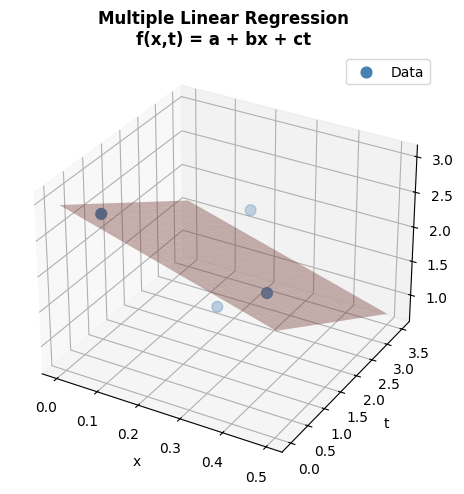

In [1]:
# ============================================================
#  BAGIAN 2: MULTIPLE LINEAR REGRESSION
#  Contoh dari Slide (Example 2)
#  Data: t, x, y seperti di bawah
#  Model: f(x,t) = a + b*x + c*t
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

print("\n" + "=" * 60)
print("  BAGIAN 2: MULTIPLE LINEAR REGRESSION")
print("=" * 60)

# --- Data ---
t2 = np.array([0, 1, 2, 3], dtype=float)
x2 = np.array([0.1, 0.4, 0.2, 0.2], dtype=float)
y2 = np.array([3, 2, 1, 2], dtype=float)
n2 = len(t2)

# --- Tabel suku-suku ---
print("\n  Tabel perhitungan:")
header = f"  {'i':<4} {'ti':<6} {'xi':<6} {'yi':<6} {'xi^2':<8} {'xi*ti':<8} {'xi*yi':<8} {'ti^2':<8} {'ti*yi':<8}"
print(header)
print("  " + "-"*72)
for i in range(n2):
    print(f"  {i+1:<4} {t2[i]:<6.1f} {x2[i]:<6.1f} {y2[i]:<6.1f} "
          f"{x2[i]**2:<8.4f} {x2[i]*t2[i]:<8.2f} {x2[i]*y2[i]:<8.2f} "
          f"{t2[i]**2:<8.1f} {t2[i]*y2[i]:<8.2f}")
print("  " + "-"*72)
print(f"  {'Sum':<4} {np.sum(t2):<6.1f} {np.sum(x2):<6.1f} {np.sum(y2):<6.1f} "
      f"{np.sum(x2**2):<8.4f} {np.sum(x2*t2):<8.2f} {np.sum(x2*y2):<8.2f} "
      f"{np.sum(t2**2):<8.1f} {np.sum(t2*y2):<8.2f}")

# --- Susun Normal Equations (3x3) ---
# n*a + Σx*b + Σt*c = Σy
# Σx*a + Σx²*b + Σxt*c = Σxy
# Σt*a + Σxt*b + Σt²*c = Σty

A2 = np.array([
    [n2,           np.sum(x2),        np.sum(t2)       ],
    [np.sum(x2),   np.sum(x2**2),     np.sum(x2*t2)    ],
    [np.sum(t2),   np.sum(x2*t2),     np.sum(t2**2)    ]
])
B2 = np.array([np.sum(y2), np.sum(x2*y2), np.sum(t2*y2)])

sol2 = np.linalg.solve(A2, B2)
a2, b2, c2 = sol2[0], sol2[1], sol2[2]

print(f"\n  Normal Equations (matrix form):")
print(f"    {A2[0]} | {B2[0]}")
print(f"    {A2[1]} | {B2[1]}")
print(f"    {A2[2]} | {B2[2]}")

print(f"\n  Solusi:")
print(f"    a = {a2:.4f}")
print(f"    b = {b2:.4f}")
print(f"    c = {c2:.4f}")
print(f"\n  Fungsi hasil: f(x,t) = {a2:.4f} + ({b2:.4f})x + ({c2:.4f})t")

y2_pred = a2 + b2*x2 + c2*t2
phi2 = np.sum((y2_pred - y2)**2)
print(f"\n  Phi (sum of squared errors) = {phi2:.6f}")

# --- Verifikasi setiap titik ---
print("\n  Verifikasi:")
print(f"  {'i':<4} {'yi':<8} {'f(xi,ti)':<12} {'error':<10} {'error^2':<10}")
print("  " + "-"*50)
for i in range(n2):
    err = y2[i] - y2_pred[i]
    print(f"  {i+1:<4} {y2[i]:<8.2f} {y2_pred[i]:<12.4f} {err:<10.4f} {err**2:<10.6f}")

# --- Plot 3D ---
fig2 = plt.figure(figsize=(8, 5))
ax2 = fig2.add_subplot(111, projection='3d')
x2_surf = np.linspace(0, 0.5, 20)
t2_surf = np.linspace(0, 3.5, 20)
X2, T2 = np.meshgrid(x2_surf, t2_surf)
Y2_surf = a2 + b2*X2 + c2*T2
ax2.plot_surface(X2, T2, Y2_surf, alpha=0.4, color='salmon')
ax2.scatter(x2, t2, y2, color='steelblue', s=60, zorder=5, label='Data')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_zlabel('y')
ax2.set_title('Multiple Linear Regression\nf(x,t) = a + bx + ct',
              fontsize=12, fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()
